In this problem, you will generate simulated data, and then perform
PCA and K-means clustering on the data.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

(a) Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can
use to generate data. One example is the normal() method of
the random() function in numpy; the uniform() method is another
option. Be sure to add a mean shift to the observations in each
class so that there are three distinct classes.

In [2]:
# 設定隨機種子，方便重現
np.random.seed(42)

n_classes = 3      # 類別數
n_samples = 20     # 每類別觀測值數量
n_features = 50    # 變數數量

# 定義每個類別的平均值（mean shift）
# 比如類別1平均0，類別2平均3，類別3平均6
means = [0, 3, 6]

# 用來存放資料與標籤
data = []
labels = []

for i, mean in enumerate(means):
    # 生成每類別的資料 (正態分布，標準差1)
    class_data = np.random.normal(loc=mean, scale=1, size=(n_samples, n_features))
    data.append(class_data)
    labels += [i] * n_samples  # 標籤 0,1,2

# 合併成一個資料集
X = np.vstack(data)
y = np.array(labels)

# 可以轉成 DataFrame 更方便操作
df = pd.DataFrame(X, columns=[f'Var{i+1}' for i in range(n_features)])
df['Class'] = y

print(df.head())
print(df['Class'].value_counts())

       Var1      Var2      Var3      Var4      Var5      Var6      Var7  \
0  0.496714 -0.138264  0.647689  1.523030 -0.234153 -0.234137  1.579213   
1  0.324084 -0.385082 -0.676922  0.611676  1.031000  0.931280 -0.839218   
2 -1.415371 -0.420645 -0.342715 -0.802277 -0.161286  0.404051  1.886186   
3  0.250493  0.346448 -0.680025  0.232254  0.293072 -0.714351  1.865775   
4  0.357787  0.560785  1.083051  1.053802 -1.377669 -0.937825  0.515035   

       Var8      Var9     Var10  ...     Var42     Var43     Var44     Var45  \
0  0.767435 -0.469474  0.542560  ...  0.171368 -0.115648 -0.301104 -1.478522   
1 -0.309212  0.331263  0.975545  ...  0.968645 -0.702053 -0.327662 -0.392108   
2  0.174578  0.257550 -0.074446  ...  1.307143 -1.607483  0.184634  0.259883   
3  0.473833 -1.191303  0.656554  ...  0.856399  0.214094 -1.245739  0.173181   
4  0.513786  0.515048  3.852731  ... -0.114736  0.504987  0.865755 -1.200296   

      Var46     Var47     Var48     Var49     Var50  Class  
0 -0.71

(b) Perform PCA on the 60 observations and plot the first two prin-
cipal component score vectors. Use a different color to indicate
the observations in each of the three classes. If the three classes
appear separated in this plot, then continue on to part (c). If
not, then return to part (a) and modify the simulation so that
there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some
separation in the first two principal component score vectors.

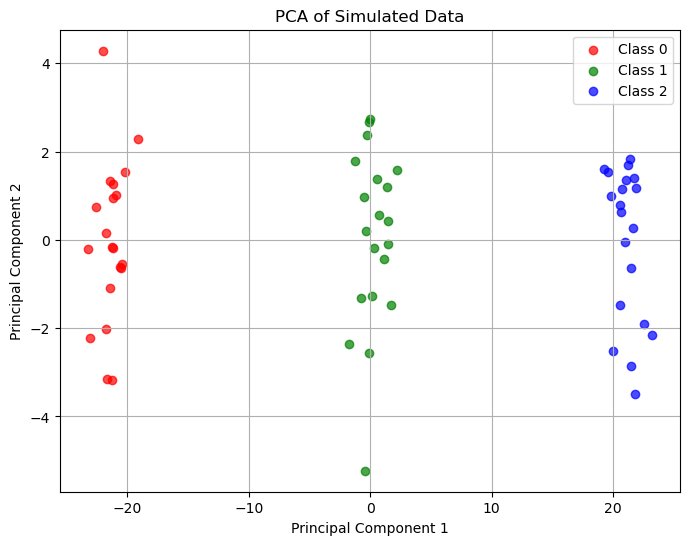

In [4]:
# 假設 df 已經有前面生成的資料，最後一欄是 Class
X = df.drop('Class', axis=1).values
y = df['Class'].values

# 建立 PCA，取前兩個主成分
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 繪圖
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']  # 每個類別的顏色
for class_idx in range(3):
    plt.scatter(
        X_pca[y==class_idx, 0],  # PC1
        X_pca[y==class_idx, 1],  # PC2
        c=colors[class_idx],
        label=f'Class {class_idx}',
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulated Data')
plt.legend()
plt.grid(True)
plt.show()

(c) Perform K-means clustering of the observations with K = 3.
How well do the clusters that you obtained in K-means clustering compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to com-
pare the true class labels to the class labels obtained by cluster-
ing. Be careful how you interpret the results: K-means clustering
will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.

In [6]:
# 特徵矩陣
X = df.drop('Class', axis=1).values
y_true = df['Class'].values

# 建立 K-means，指定 K=3
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X)

# 用 crosstab 比較 K-means 分群結果和真實類別
ct = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['K-means Cluster'])
print(ct)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0


The K-means clusters largely match the true class labels, even though the cluster numbers may differ.

(d) Perform K-means clustering with K = 2. Describe your results.

In [7]:
# 建立 K-means，指定 K=2
kmeans = KMeans(n_clusters=2, random_state=42)
y_pred = kmeans.fit_predict(X)

# 用 crosstab 比較 K-means 分群結果和真實類別
ct = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['K-means Cluster'])
print(ct)

K-means Cluster   0   1
True Class             
0                20   0
1                20   0
2                 0  20


Based on the Python result, the K-means clustering assigns all observations from the same class to the same cluster, indicating a perfect separation between the two classes.

(e) Now perform K-means clustering with K = 4, and describe your
results.

In [8]:
# 建立 K-means，指定 K=4
kmeans = KMeans(n_clusters=4, random_state=42)
y_pred = kmeans.fit_predict(X)

# 用 crosstab 比較 K-means 分群結果和真實類別
ct = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['K-means Cluster'])
print(ct)

K-means Cluster  0   1   2   3
True Class                    
0                0   0  20   0
1                8   0   0  12
2                0  20   0   0


With K=4, each cluster contains points from only a single class, maintaining the separation between the original classes.

(f) Now perform K-means clustering with K = 3 on the first two
principal component score vectors, rather than on the raw data.
That is, perform K-means clustering on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.

K-means Cluster (PCA)   0   1   2
True Class                       
0                       0   0  20
1                      20   0   0
2                       0  20   0


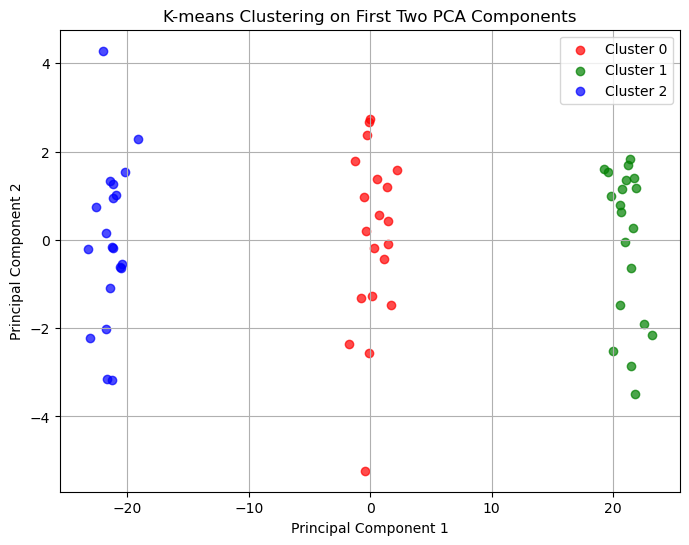

In [9]:
# 在前兩個主成分上做 K-means
kmeans_pca = KMeans(n_clusters=3, random_state=42)
y_pred_pca = kmeans_pca.fit_predict(X_pca)

# 比較 K-means 分群結果與真實類別
ct_pca = pd.crosstab(y_true, y_pred_pca, rownames=['True Class'], colnames=['K-means Cluster (PCA)'])
print(ct_pca)

colors = ['red', 'green', 'blue']
plt.figure(figsize=(8,6))
for cluster in range(3):
    plt.scatter(
        X_pca[y_pred_pca==cluster, 0],
        X_pca[y_pred_pca==cluster, 1],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering on First Two PCA Components')
plt.legend()
plt.grid(True)
plt.show()


The results also show that data from the same class are still located in the same group, even after PCA.

(g) Using the StandardScaler() estimator, perform K-means clus-
tering with K = 3 on the data after scaling each variable to have
standard deviation one. How do these results compare to those
obtained in (b)? Explain.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# 取出特徵
X = df.drop('Class', axis=1).values
y_true = df['Class'].values

# 1️⃣ 標準化：每個變數變成平均0、標準差1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2️⃣ 在標準化後的資料上做 K-means
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
y_pred_scaled = kmeans_scaled.fit_predict(X_scaled)

# 3️⃣ 比較分群結果
ct_scaled = pd.crosstab(y_true, y_pred_scaled, rownames=['True Class'], colnames=['K-means Cluster (Scaled)'])
print(ct_scaled)


K-means Cluster (Scaled)   0   1   2
True Class                          
0                          0   0  20
1                         20   0   0
2                          0  20   0


The results are still the same as those obtained in (b).